In [6]:
import pandas as pd

# Read the pipe-delimited file into a DataFrame
df = pd.read_csv("NGLI_Hold_To_ApprovedDate_1.txt", sep="|")

# Display the first few rows
df.head()

,ItemNumber,CreateTime,HoldToApprovedDate
0,439351557,08/17/2026 05:25:04 PM,8/17/2026 5:30:44 PM
1,439960182,08/25/2026 02:04:27 PM,8/25/2026 2:06:50 PM
2,440049516,08/26/2026 12:16:22 PM,9/8/2026 2:51:24 PM
3,440374856,08/30/2026 08:01:07 PM,9/8/2026 10:55:45 AM
4,440404422,08/31/2026 09:45:39 AM,9/10/2026 10:27:14 AM


In [7]:
df["CreateTime"] = pd.to_datetime(df["CreateTime"])
df["HoldToApprovedDate"] = pd.to_datetime(df["HoldToApprovedDate"])

# Calculate whole days apart

df["DaysApart"] = (df["HoldToApprovedDate"] - df["CreateTime"]).dt.days.replace(-1, 0)

# (Optional) Calculate exact fractional days apart:
# df["DaysApart"] = (df["HoldToApprovedDate"] - df["CreateTime"]).dt.total_seconds() / 86400

# Display the result
df.head()

/tmp/ipykernel_208487/1835751437.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["CreateTime"] = pd.to_datetime(df["CreateTime"])
/tmp/ipykernel_208487/1835751437.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["HoldToApprovedDate"] = pd.to_datetime(df["HoldToApprovedDate"])


,ItemNumber,CreateTime,HoldToApprovedDate,DaysApart
0,439351557,2026-08-17 17:25:04,2026-08-17 17:30:44,0
1,439960182,2026-08-25 14:04:27,2026-08-25 14:06:50,0
2,440049516,2026-08-26 12:16:22,2026-09-08 14:51:24,13
3,440374856,2026-08-30 20:01:07,2026-09-08 10:55:45,8
4,440404422,2026-08-31 09:45:39,2026-09-10 10:27:14,10


In [10]:
df.to_csv('ftni-hold-to-draw.csv', index=False)

In [8]:
pd.set_option("display.max_columns", 100)

In [9]:
df

,ItemNumber,CreateTime,HoldToApprovedDate,DaysApart
0,439351557,2026-08-17 17:25:04,2026-08-17 17:30:44,0
1,439960182,2026-08-25 14:04:27,2026-08-25 14:06:50,0
2,440049516,2026-08-26 12:16:22,2026-09-08 14:51:24,13
3,440374856,2026-08-30 20:01:07,2026-09-08 10:55:45,8
4,440404422,2026-08-31 09:45:39,2026-09-10 10:27:14,10
...,...,...,...,...
12583,437736293,2026-08-01 16:49:30,2026-08-01 16:49:27,0
12584,437736416,2026-08-01 16:54:32,2026-08-01 16:53:43,0
12585,437736447,2026-08-01 16:56:31,2026-08-01 16:55:43,0
12586,437736640,2026-08-01 17:03:28,2026-08-01 17:02:40,0


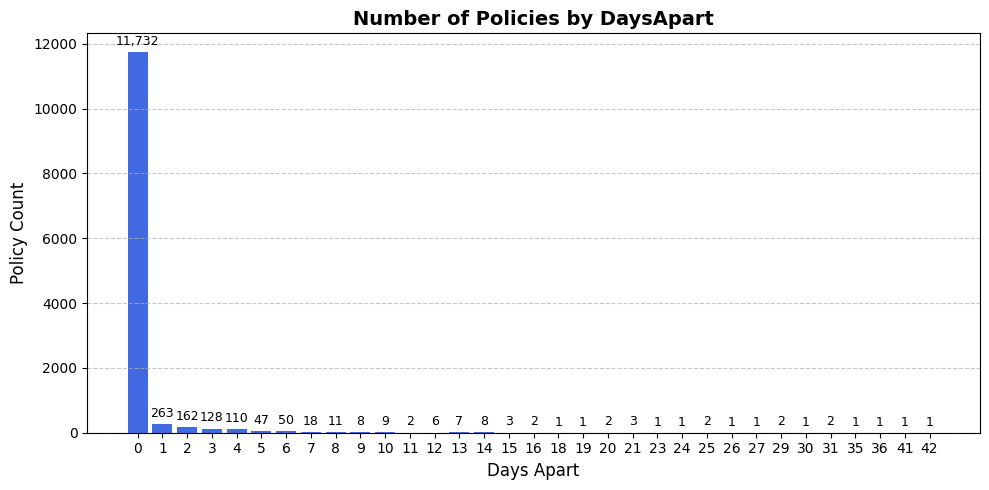

In [12]:
import matplotlib.pyplot as plt

# Group by DaysApart and count the number of policies (ItemNumber)
df_grouped = (
    df.groupby("DaysApart")["ItemNumber"]
    .count()
    .reset_index(name="PolicyCount")
)

# Plot the bar chart using matplotlib
plt.figure(figsize=(10, 5))
bars = plt.bar(
    df_grouped["DaysApart"].astype(str),
    df_grouped["PolicyCount"],
    color="royalblue",
)

# Add chart labels, grid, and title
plt.title("Number of Policies by DaysApart", fontsize=14, fontweight="bold")
plt.xlabel("Days Apart", fontsize=12)
plt.ylabel("Policy Count", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Display exact counts above each bar
for bar in bars:
    height = bar.get_height()
    if height > 0:
        plt.annotate(
            f"{int(height):,}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )

plt.tight_layout()
plt.show()